<div>

# MNIST Handwritten Digit Classification Using ANN

## Artificial Neural Network Based Image Classification

**Project Type:** Machine Learning / Deep Learning  
**Dataset:** MNIST Handwritten Digits  
**Model:** Artificial Neural Network (ANN)  
**Framework:** TensorFlow / Keras  
**Preprocessing:** StandardScaler + One-Hot Encoding  

</div>

# Install/Import

In [3]:
!pip install -q idx2numpy

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import idx2numpy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input

# Load Dataset

In [5]:
train_images_path = "/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte"
train_labels_path = "/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte"

test_images_path = "/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte"
test_labels_path = "/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte"

In [6]:
X = idx2numpy.convert_from_file(train_images_path)
y = idx2numpy.convert_from_file(train_labels_path)

X_test = idx2numpy.convert_from_file(test_images_path)
y_test = idx2numpy.convert_from_file(test_labels_path)

print("Training images:", X.shape)
print("Training labels:", y.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


# Visualization

## Single Image

In [7]:
X[0].shape

(28, 28)

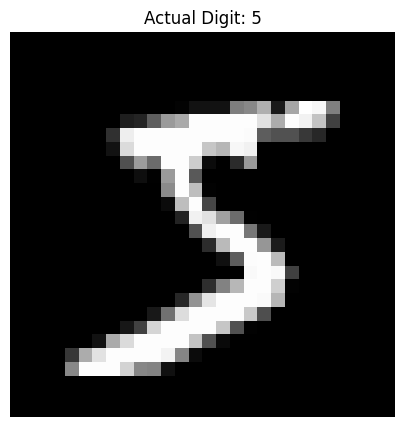

In [8]:
plt.figure(figsize=(5, 5))

plt.imshow(X[0], cmap="gray")

plt.title(f"Actual Digit: {y[0]}")

plt.axis("off")
plt.show()

## Multiple Images 

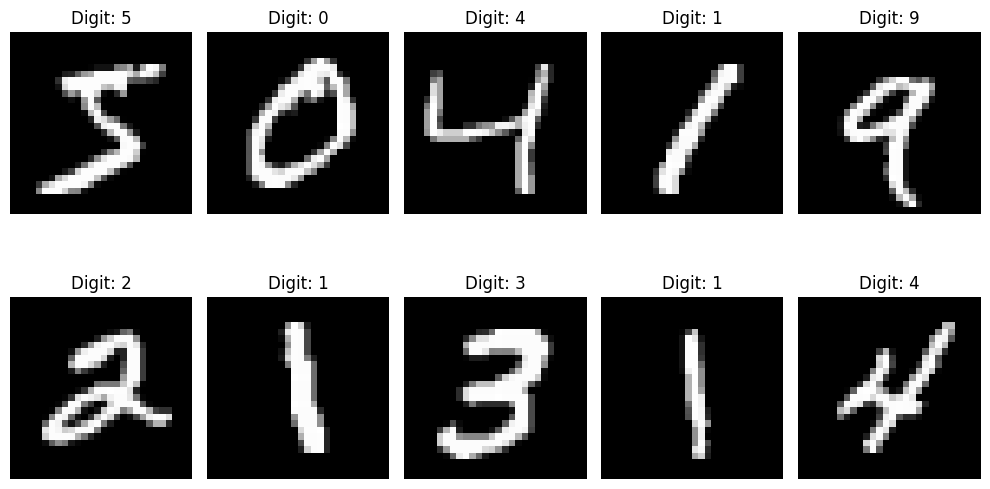

In [9]:
plt.figure(figsize=(10, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X[i],
        cmap="gray"
    )

    plt.title(
        f"Digit: {y[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Flatten Images 

In [10]:
X.shape[1] * X.shape[2]

784

In [11]:
X = X.reshape(X.shape[0], X.shape[1]*X.shape[2])

X_test = X_test.reshape(
    X_test.shape[0],
    784
)

print("X:", X.shape)
print("X_test:", X_test.shape)

X: (60000, 784)
X_test: (10000, 784)


# Train/Validation Split

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


# Standard Scaler

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(54000, 784)
(6000, 784)
(10000, 784)


# One-Hot Encode Labels

In [14]:
y_train = to_categorical(
    y_train,
    num_classes=10
)

y_val = to_categorical(
    y_val,
    num_classes=10
)

y_test = to_categorical(
    y_test,
    num_classes=10
)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

y_train: (54000, 10)
y_val: (6000, 10)
y_test: (10000, 10)


In [16]:
y_train[2]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

# Build ANN

In [18]:
model = Sequential()

model.add(Input((X_train.shape[1],)))

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dense(
        64,
        activation="relu"
    )
)

model.add(
    Dense(
        10,
        activation="softmax"
    )
)

model.summary()

2026-08-24 09:57:02.147919: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [19]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Train

In [28]:
54000/128

421.875

In [29]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val)
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9107 - loss: 0.3040 - val_accuracy: 0.9477 - val_loss: 0.2046
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9679 - loss: 0.1089 - val_accuracy: 0.9587 - val_loss: 0.1761
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9778 - loss: 0.0717 - val_accuracy: 0.9660 - val_loss: 0.1605
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9851 - loss: 0.0483 - val_accuracy: 0.9682 - val_loss: 0.1625
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9896 - loss: 0.0340 - val_accuracy: 0.9672 - val_loss: 0.1802
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9936 - loss: 0.0235 - val_accuracy: 0.9667 - val_loss: 0.1936
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9941 - loss: 0.0199 - val_accuracy: 0.9673 - val_loss: 0.1877
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9946 - loss: 0.0184 - val_accuracy: 0.

# Evaluate

In [31]:
10000/32

312.5

In [30]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.3193
Test Loss: 0.31929436326026917
Test Accuracy: 0.9735000133514404
Test Accuracy (%): 97.35000133514404


# Accuracy Graph

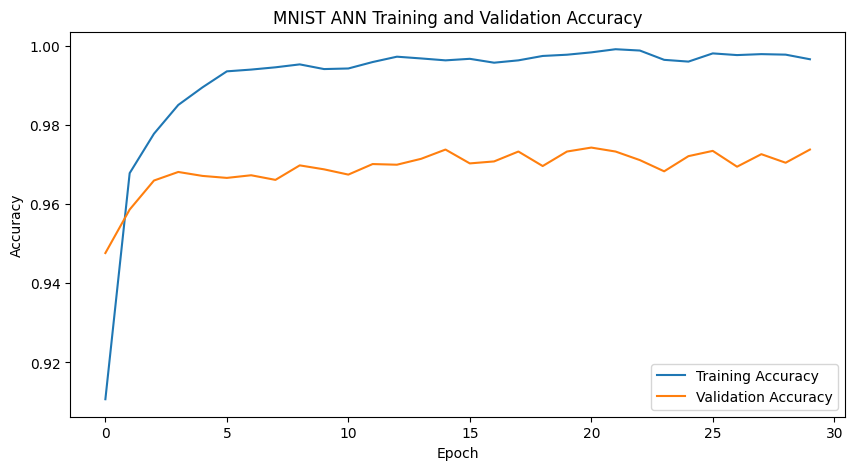

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "MNIST ANN Training and Validation Accuracy"
)

plt.legend()
plt.show()

# Loss Graph

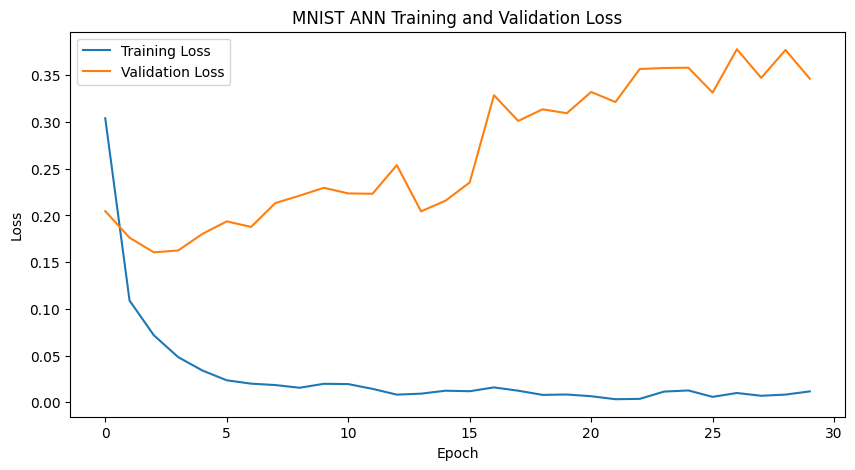

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "MNIST ANN Training and Validation Loss"
)

plt.legend()
plt.show()

# Predictions 

In [34]:
y_pred_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [38]:
np.argmax(y_pred_prob[0])

np.int64(7)

In [41]:
np.argmax(y_pred_prob, axis=1)

array([7, 2, 1, ..., 4, 5, 6])

In [42]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_actual = np.argmax(
    y_test,
    axis=1
)

print("Predicted:", y_pred[:10])
print("Actual:   ", y_actual[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


# Visualize Prediction

In [48]:
np.argmax(y_test[0])

np.int64(7)

In [50]:
X_test[0].reshape(-1, 784).shape

(1, 784)

In [52]:
single_prob = model.predict(X_test[0].reshape(-1, 784))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [54]:
np.argmax(single_prob)

np.int64(7)

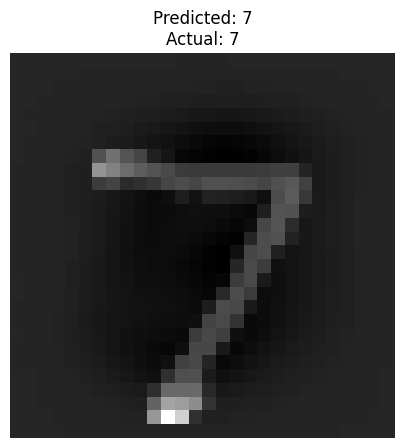

In [55]:
index = 0

plt.figure(figsize=(5, 5))

plt.imshow(
    X_test[index].reshape(28, 28),
    cmap="gray"
)

plt.title(
    f"Predicted: {y_pred[index]}\n"
    f"Actual: {y_actual[index]}"
)

plt.axis("off")
plt.show()

# Multiple Predictions

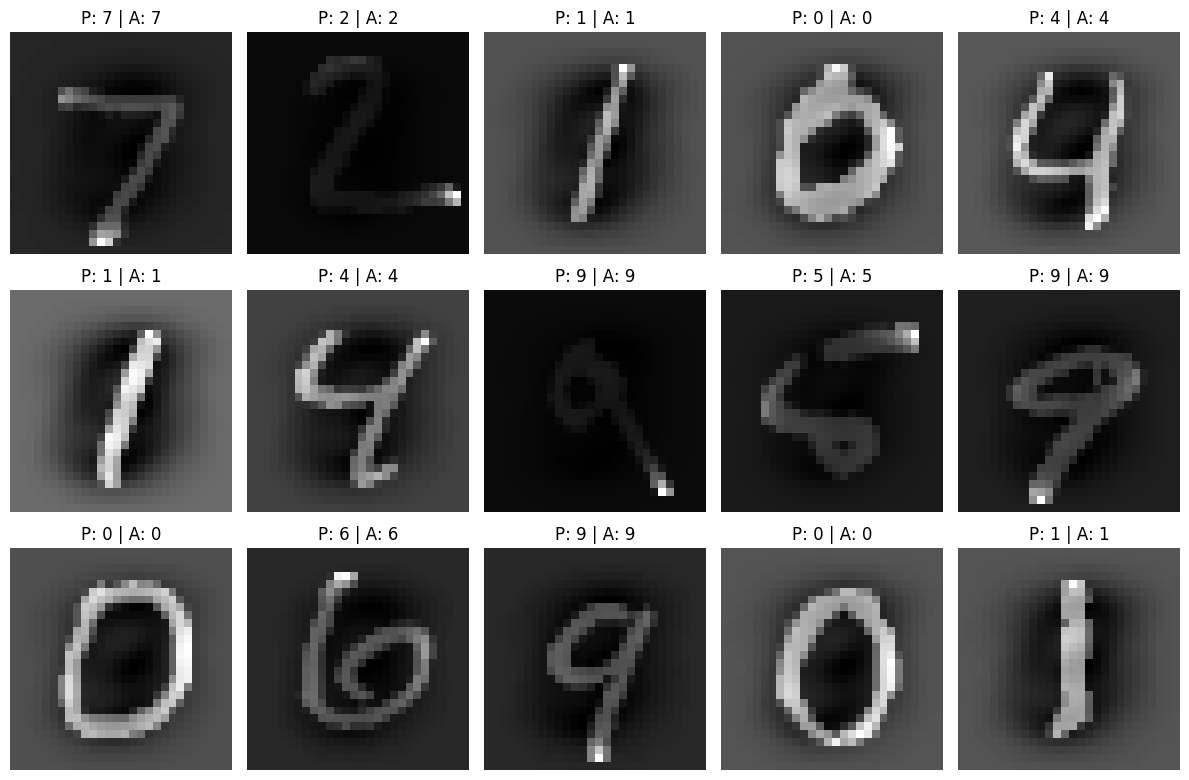

In [56]:
plt.figure(figsize=(12, 8))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"P: {y_pred[i]} | A: {y_actual[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

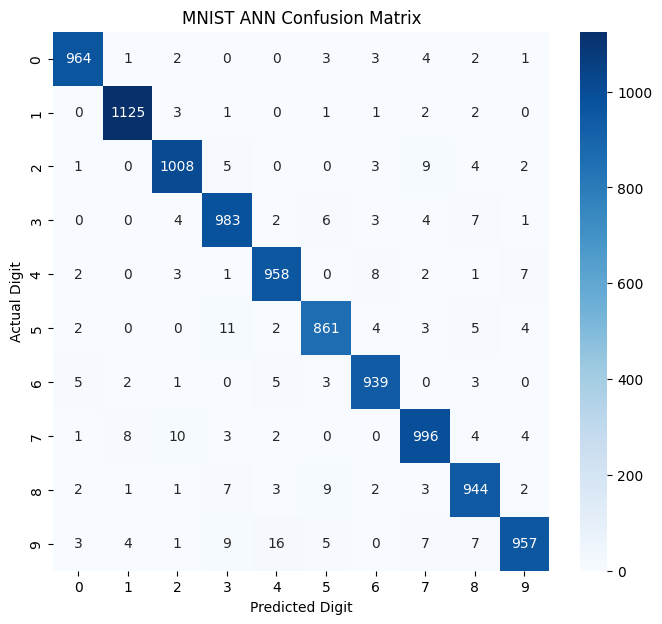

In [57]:
import seaborn as sns

cm = confusion_matrix(
    y_actual,
    y_pred
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.title(
    "MNIST ANN Confusion Matrix"
)

plt.show()

In [58]:
print(
    classification_report(
        y_actual,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.96      0.97      0.97      1010
           4       0.97      0.98      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.97      0.97       974
           9       0.98      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [59]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.3193
Test Loss: 0.31929436326026917
Test Accuracy: 0.9735000133514404


In [60]:
model.save(
    "/kaggle/working/mnist_ann.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [61]:
from IPython.display import FileLink

model_path = "/kaggle/working/mnist_ann.keras"

print("Model saved successfully!")
FileLink(model_path)

Model saved successfully!


/kaggle/working/mnist_ann.keras

In [ ]:
# Save the trained ANN model
model.save("/kaggle/working/mnist_ann.keras")

print("Model saved successfully!")

# Create download link
from IPython.display import FileLink

FileLink("/kaggle/working/mnist_ann.keras")

<div >

## Results

**Test Accuracy:** `97%`  
**Test Loss:** `3.5%`

The model achieved an overall test accuracy of **97%**, with a macro-average F1-score of **0.97** and a weighted-average F1-score of **0.97**. The results demonstrate that the ANN performs consistently well across all ten MNIST digit classes.

</div>